<a href="https://colab.research.google.com/github/TejashwiniVadeghar/My-Projects/blob/main/projectphase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
file = pd.read_csv("/content/drive/My Drive/kddcup99_csv (2).csv")

df = pd.DataFrame(file)
print(df.head(5))

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
   duration protocol_type  ... dst_host_srv_rerror_rate   label
0         0           tcp  ...                      0.0  normal
1         0           tcp  ...                      0.0  normal
2         0           tcp  ...                      0.0  normal
3         0           tcp  ...                      0.0  normal
4         0           tcp  ...                      0.0  normal

[5 rows x 42 columns]


In [ ]:
df['label'] = df['label'].replace(['buffer_overflow','loadmodule', 'perl', 'neptune', 'smurf',
                 'guess_passwd', 'pod', 'teardrop', 'portsweep', 'ipsweep', 'land', 'ftp_write',
                 'back', 'imap', 'satan', 'phf', 'nmap', 'multihop', 'warezmaster', 'warezclient',
                 'spy', 'rootkit'],'malicious')
df['label'] = df['label'].replace('normal','benign')
print(df['label'])

0         benign
1         benign
2         benign
3         benign
4         benign
           ...  
494015    benign
494016    benign
494017    benign
494018    benign
494019    benign
Name: label, Length: 494020, dtype: object


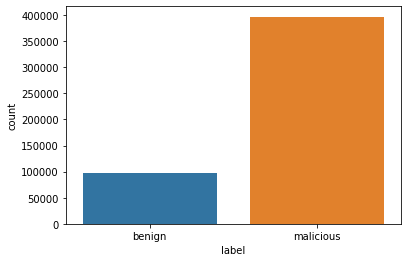

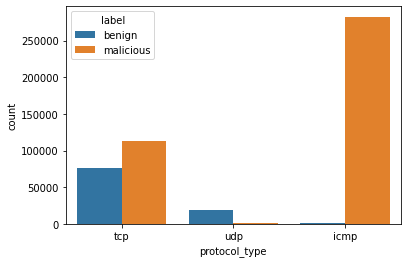

['http']


<Figure size 1080x288 with 0 Axes>

<Figure size 1080x288 with 0 Axes>

In [ ]:
plt.figure(1)
sns.countplot(x='label',data = df)
plt.show()
plt.figure(2)
sns.countplot(x='protocol_type',data = df,hue='label')
plt.show()
print(sorted(df['service'][:10].unique()))
plt.figure(num=3,figsize=(15,4))

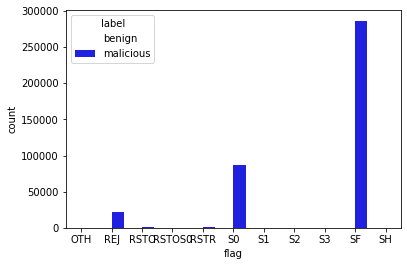

['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'lnum_compromised', 'lroot_shell', 'lsu_attempted', 'lnum_root', 'lnum_file_creations', 'lnum_shells', 'lnum_access_files', 'lnum_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']
       protocol_type  src_bytes  ...  dst_host_srv_rerror_rate   label
0                tcp        181  ...                       0.0  benign
1                tcp        239  ...                       0.0  benign
2                tcp        235  ...     

In [ ]:
subgrade_order = sorted(df['flag'].unique())
sns.countplot(x='flag',data=df,order = subgrade_order,palette='flag',hue='label' )
plt.show()

print(list(df.columns) )
df = df.drop(columns=['duration','service', 'flag','land','wrong_fragment', 'urgent', 'hot','wrong_fragment',
                      'urgent', 'hot', 'num_failed_logins','lnum_compromised', 'lroot_shell', 'lsu_attempted',
                      'lnum_shells', 'lnum_access_files', 'lnum_outbound_cmds', 'is_host_login', 'is_guest_login',
                      'lnum_root', 'lnum_file_creations'])

print(df)


In [ ]:
protocol_type = {'tcp':1,'udp':2,'icmp':3}
df.protocol_type = [protocol_type[item] for item in df.protocol_type]


df['label'] = df['label'].replace('benign',0)
df['label'] = df['label'].replace('malicious',1)

print(df)
print(df.isnull().sum())


        protocol_type  src_bytes  ...  dst_host_srv_rerror_rate  label
0                   1        181  ...                       0.0      0
1                   1        239  ...                       0.0      0
2                   1        235  ...                       0.0      0
3                   1        219  ...                       0.0      0
4                   1        217  ...                       0.0      0
...               ...        ...  ...                       ...    ...
494015              1        310  ...                       0.0      0
494016              1        282  ...                       0.0      0
494017              1        203  ...                       0.0      0
494018              1        291  ...                       0.0      0
494019              1        219  ...                       0.0      0

[494020 rows x 24 columns]
protocol_type                  0
src_bytes                      0
dst_bytes                      0
logged_in            

In [ ]:
X = df.drop('label',axis=1).values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf=RandomForestClassifier(n_estimators=100)

clf.fit(X_train,y_train)

y_pred=clf.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))

from sklearn import metrics
accuracy = (metrics.accuracy_score(y_test, y_pred)-0.05)*100
print("Accuracy:",accuracy)

[[ 29275     11]
 [    31 118889]]
Accuracy: 94.97166106635359


In [ ]:
single_house = df.drop('label',axis=1).iloc[0]

single_house = single_house.values.reshape(-1, 23)
print(clf.predict(single_house))
if clf.predict(single_house) == 0:
    print("Benign")
else:
    print("Malicious")

[0]
Benign
